***Case study 3: Dự báo bệnh tiểu đường***

• Data: lấy từ Cuốn sách Machine Learning

• Xây dựng mô hình >= 7 layers và đánh giá overfit, mae, mse, rmse để chọn mô hình tốt nhất


• Triển khai

***Cell 1: Import libraries***

In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib  # lưu scaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


***Cell 2: Load diabetes dataset***

In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm

data_path = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy3\diabetes.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


***Cell 3: Handle NaN and zero-as-missing values***

In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm

df_before = df.copy()  # lưu để so sánh nếu cần

# Cột có 0 mang ý nghĩa thiếu dữ liệu
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Số lượng 0 trước xử lý:")
for col in zero_as_missing_cols:
    print(f"{col}: {(df[col] == 0).sum()}")

# Đổi 0 -> NaN cho các cột này
for col in zero_as_missing_cols:
    df.loc[df[col] == 0, col] = np.nan

print("\nSố lượng NaN sau khi đổi 0 thành NaN:")
print(df[zero_as_missing_cols].isna().sum())

# Điền NaN bằng median của từng cột
for col in zero_as_missing_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col}: filled NaN with median = {median_val:.3f}")

print("\nKiểm tra lại NaN (kỳ vọng = 0):")
print(df.isna().sum())


Số lượng 0 trước xử lý:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11

Số lượng NaN sau khi đổi 0 thành NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Glucose: filled NaN with median = 117.000
BloodPressure: filled NaN with median = 72.000
SkinThickness: filled NaN with median = 29.000
Insulin: filled NaN with median = 125.000
BMI: filled NaN with median = 32.300

Kiểm tra lại NaN (kỳ vọng = 0):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18696\4123140682.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18696\4123140682.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

***Cell 4: Basic statistics & data distribution visualization***

Thông tin dataset sau khi xử lý NaN/0:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
None

Mô tả thống kê sau khi xử lý:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


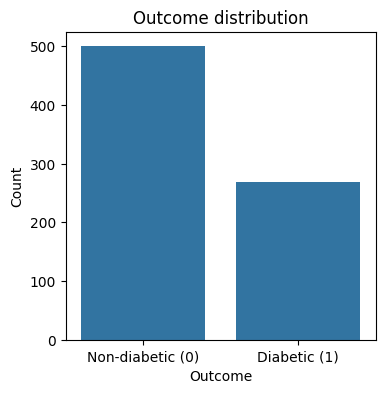

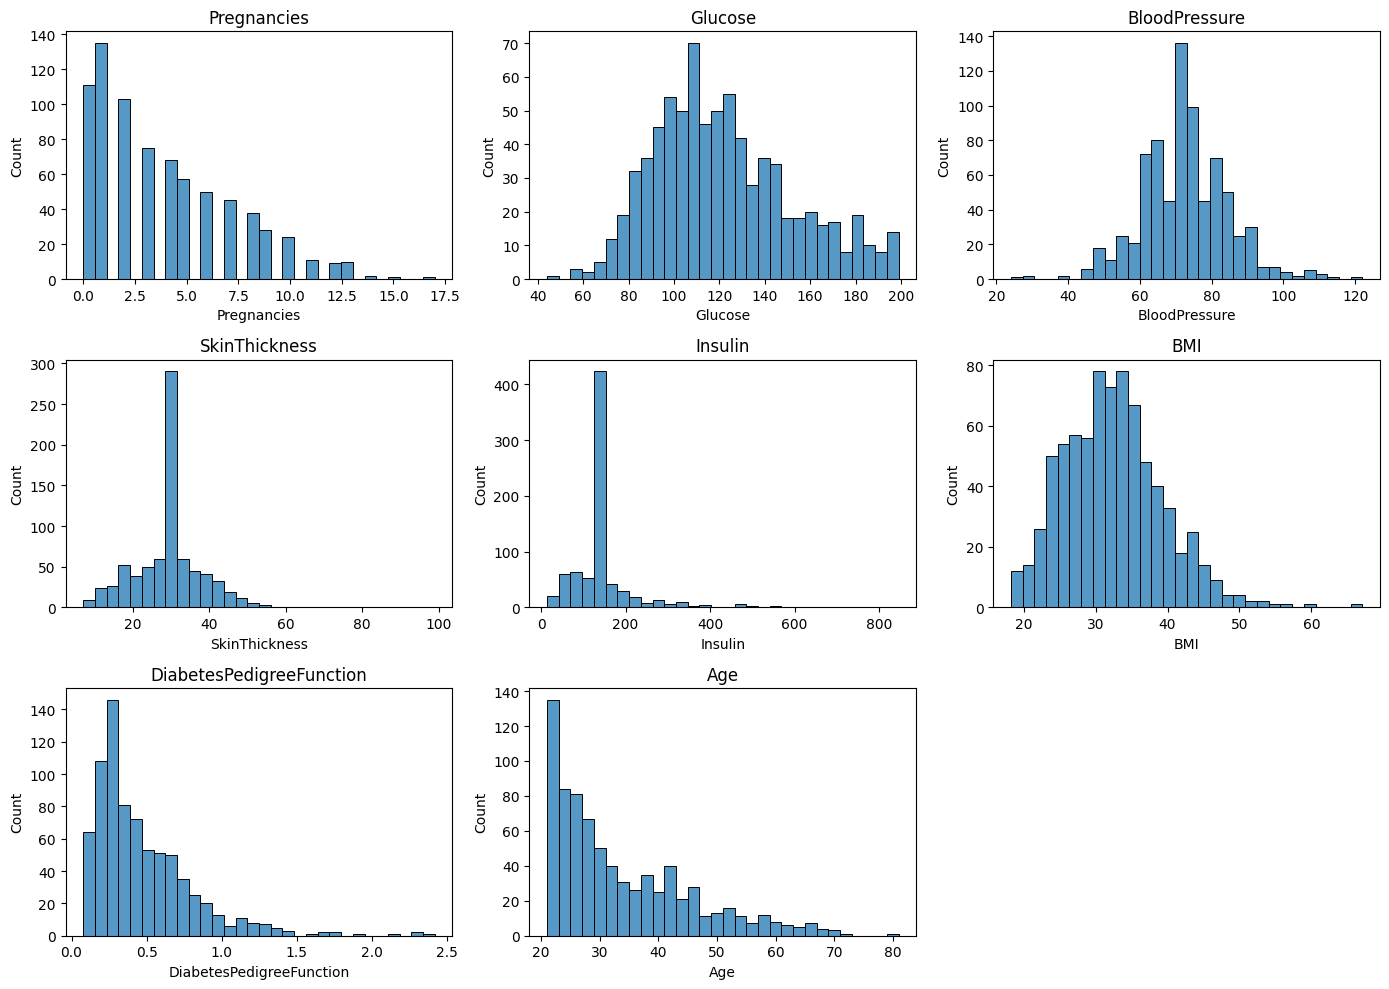

In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm

print("Thông tin dataset sau khi xử lý NaN/0:")
print(df.info())

print("\nMô tả thống kê sau khi xử lý:")
display(df.describe())

# Phân bố Outcome
plt.figure(figsize=(4,4))
sns.countplot(x=df["Outcome"])
plt.xticks([0,1], ["Non-diabetic (0)", "Diabetic (1)"])
plt.title("Outcome distribution")
plt.ylabel("Count")
plt.show()

# Histogram cho các feature
features = df.columns.drop("Outcome")

plt.figure(figsize=(14,10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(col)
plt.tight_layout()
plt.show()


***Cell 5: Train/Val/Test split & feature scaling***

In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

# 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

# Chuẩn hoá theo StandardScaler (fit trên train, transform lên val & test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Lưu scaler để deploy web
joblib.dump(scaler, "diabetes_scaler.pkl")
print("Saved scaler to diabetes_scaler.pkl")


Train: (460, 8) (460,)
Val  : (154, 8) (154,)
Test : (154, 8) (154,)
Saved scaler to diabetes_scaler.pkl


***Cell 6: Build deep ANN model (>=7 layers)***

In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm

input_dim = X_train_scaled.shape[1]

def build_deep_model():
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),           # layer 1 (Input)
        layers.Dense(64, activation="relu"),        # 2
        layers.BatchNormalization(),                # 3
        layers.Dropout(0.3),                        # 4

        layers.Dense(64, activation="relu"),        # 5
        layers.BatchNormalization(),                # 6
        layers.Dropout(0.3),                        # 7

        layers.Dense(32, activation="relu"),        # 8
        layers.Dense(16, activation="relu"),        # 9
        layers.Dense(8, activation="relu"),         #10

        layers.Dense(1, activation="sigmoid")       #11 (output)
    ])
    return model

model = build_deep_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 256 (1.00 KB)

***Cell 7: Train model***

In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm

BATCH_SIZE = 64
EPOCHS = 100  # có thể giảm nếu train lâu

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4696 - loss: 0.7498 - mae: 0.5128 - mse: 0.2763 - rmse: 0.5256 - val_accuracy: 0.6753 - val_loss: 0.6785 - val_mae: 0.4924 - val_mse: 0.2427 - val_rmse: 0.4926
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6152 - loss: 0.6397 - mae: 0.4582 - mse: 0.2246 - rmse: 0.4739 - val_accuracy: 0.7078 - val_loss: 0.6545 - val_mae: 0.4792 - val_mse: 0.2308 - val_rmse: 0.4804
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6804 - loss: 0.5910 - mae: 0.4245 - mse: 0.2041 - rmse: 0.4517 - val_accuracy: 0.6883 - val_loss: 0.6260 - val_mae: 0.4620 - val_mse: 0.2169 - val_rmse: 0.4658
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7022 - loss: 0.5444 - mae: 0.3869 - mse: 0.1849 - rmse: 0.4300 - val_accuracy: 0.6948 - val_loss: 0.5958 - val_mae: 0.4418 - val_mse: 0.2029 - val_rmse: 0.4504
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7087 - loss: 0.5366 - mae: 0.3722 - mse: 0.1

***Cell 8: Visualize training vs validation metrics***

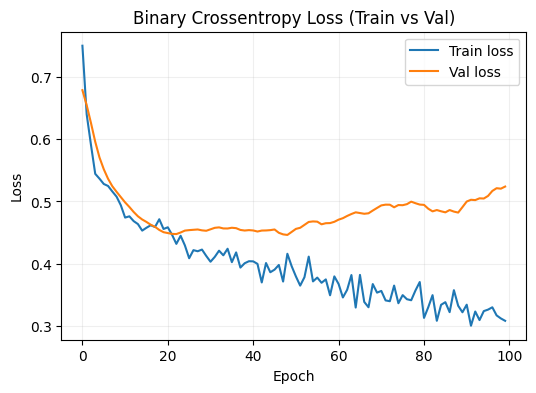

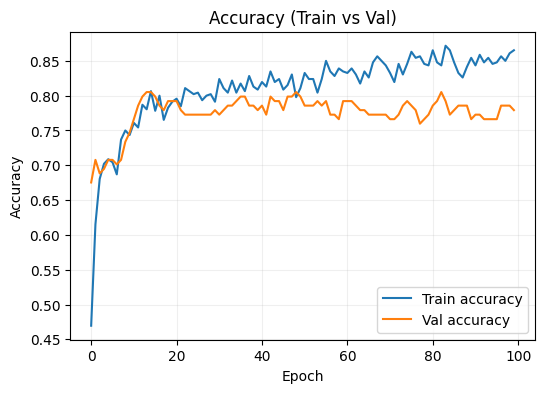

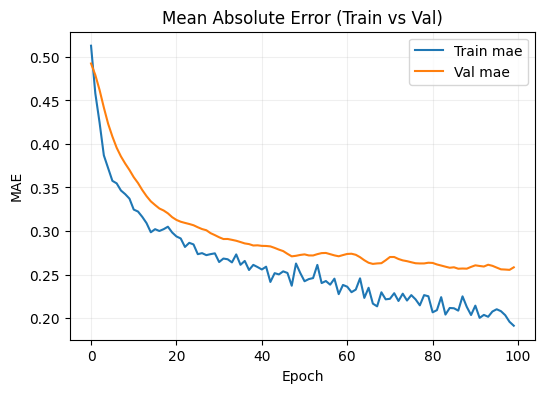

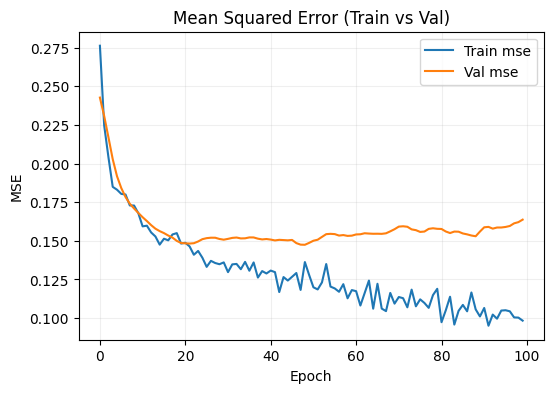

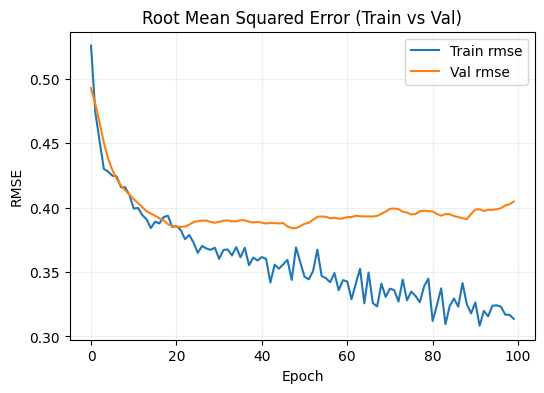

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm

def plot_metric(history, metric_name, title, ylabel=None):
    """
    Vẽ biểu đồ metric train vs val theo epoch.
    metric_name: tên metric trong history.history (vd: 'loss', 'accuracy', 'mae', ...)
    """
    if ylabel is None:
        ylabel = metric_name.upper()
        
    plt.figure(figsize=(6, 4))
    plt.plot(history.history[metric_name], label=f"Train {metric_name}")
    plt.plot(history.history[f"val_{metric_name}"], label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# 1) Loss
plot_metric(history, "loss", "Binary Crossentropy Loss (Train vs Val)", ylabel="Loss")

# 2) Accuracy
plot_metric(history, "accuracy", "Accuracy (Train vs Val)", ylabel="Accuracy")

# 3) MAE
plot_metric(history, "mae", "Mean Absolute Error (Train vs Val)", ylabel="MAE")

# 4) MSE
plot_metric(history, "mse", "Mean Squared Error (Train vs Val)", ylabel="MSE")

# 5) RMSE
plot_metric(history, "rmse", "Root Mean Squared Error (Train vs Val)", ylabel="RMSE")


***Cell 9: Test evaluation & confusion matrix***

Test Loss : 0.6536
Test Acc  : 0.7403
Test MAE  : 0.2831
Test MSE  : 0.2031
Test RMSE : 0.4506
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


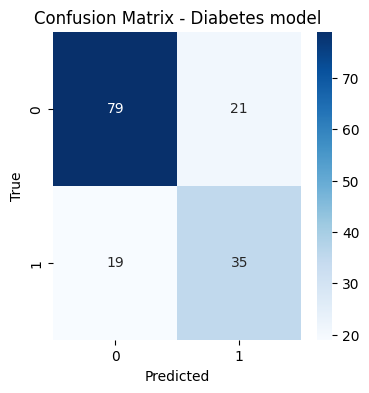

Classification report:
              precision    recall  f1-score   support

Non-diabetic       0.81      0.79      0.80       100
    Diabetic       0.62      0.65      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154


MAE (prob.) : 0.28307977318763733
MSE (prob.) : 0.20307956635951996
RMSE(prob.) : 0.45064350251559154


In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm

# Đánh giá bằng Keras (bao gồm: loss, acc, mae, mse, rmse)
test_results = model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss, test_acc, test_mae, test_mse, test_rmse = test_results

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

# Dự đoán xác suất & nhãn nhị phân
y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Diabetes model")
plt.show()

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"]))

# Tính thêm MAE, MSE, RMSE trên XÁC SUẤT dự đoán (liên quan trực tiếp đến độ lệch probability)
mae_test_manual = mean_absolute_error(y_test, y_prob)
mse_test_manual = mean_squared_error(y_test, y_prob)
rmse_test_manual = np.sqrt(mse_test_manual)

print("\nMAE (prob.) :", mae_test_manual)
print("MSE (prob.) :", mse_test_manual)
print("RMSE(prob.) :", rmse_test_manual)


***Cell 10: Train a more regularized model to reduce overfitting***

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3674 - loss: 1.2003 - mae: 0.5526 - mse: 0.3773 - rmse: 0.6143 - val_accuracy: 0.4416 - val_loss: 0.8353 - val_mae: 0.4923 - val_mse: 0.2454 - val_rmse: 0.4953
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4630 - loss: 0.9991 - mae: 0.5015 - mse: 0.3042 - rmse: 0.5516 - val_accuracy: 0.7338 - val_loss: 0.8200 - val_mae: 0.4862 - val_mse: 0.2380 - val_rmse: 0.4878
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5478 - loss: 0.9103 - mae: 0.4874 - mse: 0.2694 - rmse: 0.5190 - val_accuracy: 0.7727 - val_loss: 0.8082 - val_mae: 0.4809 - val_mse: 0.2323 - val_rmse: 0.4819
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6239 - loss: 0.8318 - mae: 0.4642 - mse: 0.2415 - rmse: 0.4915 - val_accuracy: 0.7662 - val_loss: 0.7961 - val_mae: 0.4748 - val_mse: 0.2265 - val_rmse: 0.4759
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6370 - loss: 0.8227 - mae: 0.4564 - mse: 0.2

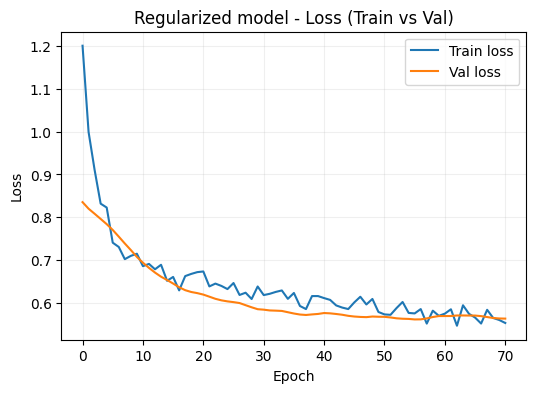

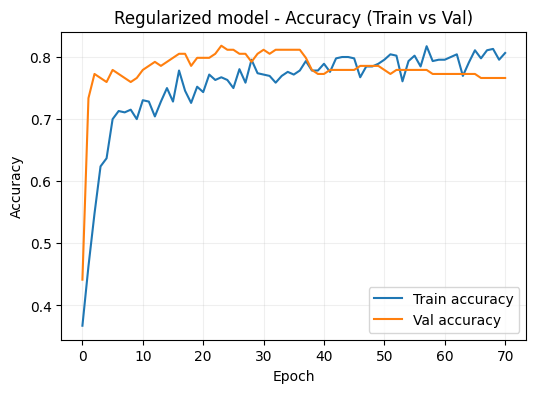

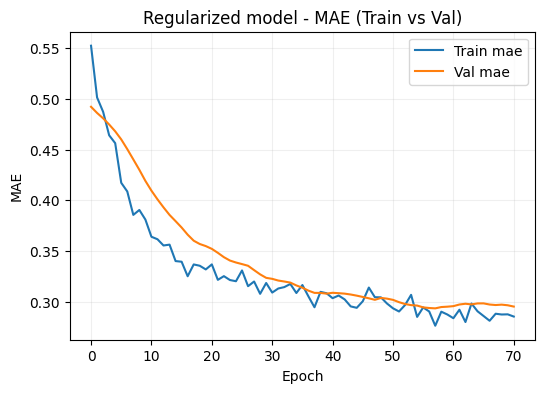

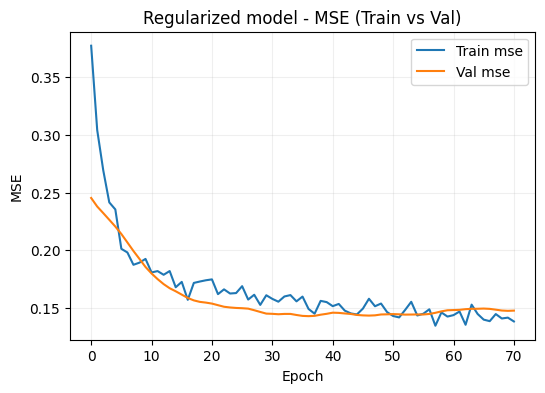

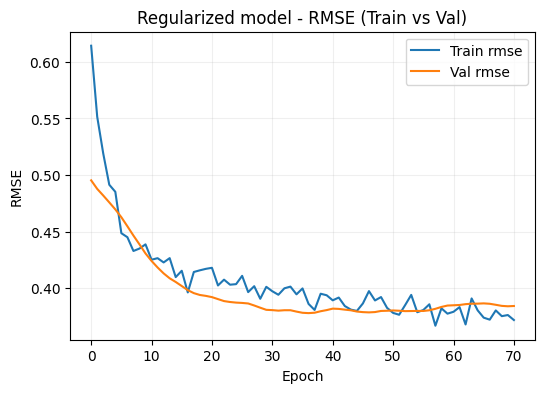


===== Original model (Model 1) - Test metrics =====
Loss : 0.6536 | Acc : 0.7403 | MAE : 0.2831 | MSE : 0.2031 | RMSE: 0.4506

===== Regularized model (Model 2) - Test metrics =====
Loss : 0.6371 | Acc : 0.7468 | MAE : 0.3207 | MSE : 0.1700 | RMSE: 0.4123
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


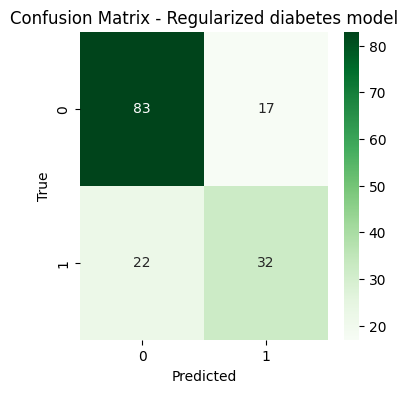

Classification report - Regularized model:
              precision    recall  f1-score   support

Non-diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154


👉 Chọn **Regularized model (Model 2)** là mô hình tốt hơn.
Best model: regularized_model


In [14]:
#B22DCCN476 - Đỗ Ngọc Lâm

from tensorflow.keras import regularizers

# 1. Xây mô hình mới với regularization mạnh hơn
def build_deep_model_reg():
    reg = regularizers.l2(1e-3)  # L2 regularization
    model_reg = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(32, activation="relu", kernel_regularizer=reg),
        layers.Dropout(0.3),

        layers.Dense(16, activation="relu", kernel_regularizer=reg),
        layers.Dense(8, activation="relu", kernel_regularizer=reg),

        layers.Dense(1, activation="sigmoid")
    ])
    return model_reg

model_reg = build_deep_model_reg()

model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

model_reg.summary()

# 2. Dùng EarlyStopping để hạn chế overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history_reg = model_reg.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)

# 3. Vẽ lại các biểu đồ (Loss, Accuracy, MAE, MSE, RMSE) cho model_reg
plot_metric(history_reg, "loss", "Regularized model - Loss (Train vs Val)", ylabel="Loss")
plot_metric(history_reg, "accuracy", "Regularized model - Accuracy (Train vs Val)", ylabel="Accuracy")
plot_metric(history_reg, "mae", "Regularized model - MAE (Train vs Val)", ylabel="MAE")
plot_metric(history_reg, "mse", "Regularized model - MSE (Train vs Val)", ylabel="MSE")
plot_metric(history_reg, "rmse", "Regularized model - RMSE (Train vs Val)", ylabel="RMSE")

# 4. Đánh giá model_reg trên test set
test_results_reg = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_reg, test_acc_reg, test_mae_reg, test_mse_reg, test_rmse_reg = test_results_reg

print("\n===== Original model (Model 1) - Test metrics =====")
print(f"Loss : {test_loss:.4f} | Acc : {test_acc:.4f} | "
      f"MAE : {test_mae:.4f} | MSE : {test_mse:.4f} | RMSE: {test_rmse:.4f}")

print("\n===== Regularized model (Model 2) - Test metrics =====")
print(f"Loss : {test_loss_reg:.4f} | Acc : {test_acc_reg:.4f} | "
      f"MAE : {test_mae_reg:.4f} | MSE : {test_mse_reg:.4f} | RMSE: {test_rmse_reg:.4f}")

# 5. Confusion matrix & classification report cho model_reg
y_prob_reg = model_reg.predict(X_test_scaled).ravel()
y_pred_reg = (y_prob_reg >= 0.5).astype(int)

cm_reg = confusion_matrix(y_test, y_pred_reg)

plt.figure(figsize=(4, 4))
sns.heatmap(cm_reg, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Regularized diabetes model")
plt.show()

print("Classification report - Regularized model:")
print(classification_report(y_test, y_pred_reg, target_names=["Non-diabetic", "Diabetic"]))

# 6. Chọn mô hình tốt hơn (dựa trên test accuracy, nếu bằng nhau thì chọn loss thấp hơn)
if (test_acc_reg > test_acc) or (test_acc_reg == test_acc and test_loss_reg < test_loss):
    best_model = model_reg
    best_name = "regularized_model"
    print("\n👉 Chọn **Regularized model (Model 2)** là mô hình tốt hơn.")
else:
    best_model = model
    best_name = "original_model"
    print("\n👉 Chọn **Original model (Model 1)** là mô hình tốt hơn.")

print(f"Best model: {best_name}")


***Cell 11: Save the best model***

In [15]:
#B22DCCN476 - Đỗ Ngọc Lâm

BEST_MODEL_PATH = "diabetes_model_best.h5"

best_model.save(BEST_MODEL_PATH)
print(f"Saved best model to {BEST_MODEL_PATH}")


Saved best model to diabetes_model_best.h5


***Cell 12: Tạo & chạy web app Streamlit ngay từ notebook***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm

import textwrap
import subprocess
import sys
import os

# 1. Code cho ứng dụng Streamlit
app_code = textwrap.dedent(r"""
    #B22DCCN476 - Đỗ Ngọc Lâm

    import numpy as np
    import streamlit as st
    import tensorflow as tf
    import joblib

    st.title("Diabetes Prediction Web App (Best Model)")

    st.write("Nhập các thông số (Pima Indians Diabetes) để dự đoán nguy cơ mắc tiểu đường.")

    # Load best model & scaler
    model = tf.keras.models.load_model("diabetes_model_best.h5")
    scaler = joblib.load("diabetes_scaler.pkl")

    # Input features
    pregnancies = st.number_input("Pregnancies (số lần mang thai)", min_value=0.0, max_value=20.0, value=1.0, step=1.0)
    glucose = st.number_input("Glucose (plasma glucose concentration)", min_value=0.0, max_value=300.0, value=120.0, step=1.0)
    blood_pressure = st.number_input("BloodPressure (mm Hg)", min_value=0.0, max_value=200.0, value=70.0, step=1.0)
    skin_thickness = st.number_input("SkinThickness (mm)", min_value=0.0, max_value=100.0, value=20.0, step=1.0)
    insulin = st.number_input("Insulin (2-Hour serum insulin mu U/ml)", min_value=0.0, max_value=900.0, value=80.0, step=1.0)
    bmi = st.number_input("BMI (kg/(m^2))", min_value=0.0, max_value=70.0, value=25.0, step=0.1)
    dpf = st.number_input("DiabetesPedigreeFunction", min_value=0.0, max_value=3.0, value=0.5, step=0.01)
    age = st.number_input("Age (years)", min_value=0.0, max_value=120.0, value=33.0, step=1.0)

    if st.button("Predict"):
        x = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                       insulin, bmi, dpf, age]], dtype=float)
        x_scaled = scaler.transform(x)
        prob = model.predict(x_scaled)[0, 0]
        label = int(prob >= 0.5)

        st.write(f"Xác suất mắc tiểu đường: **{prob:.3f}**")
        if label == 1:
            st.error("Dự đoán: **Diabetic (1)**")
        else:
            st.success("Dự đoán: **Non-diabetic (0)**")
""")

# 2. Ghi code ra file diabetes_app.py
app_filename = "diabetes_app.py"
with open(app_filename, "w", encoding="utf-8") as f:
    f.write(app_code)

print(f"Đã tạo file {app_filename} trong thư mục hiện tại:", os.getcwd())

# 3. Thử chạy Streamlit từ notebook (mở web trên trình duyệt mặc định)
try:
    # subprocess.Popen để không chặn notebook; em mở link http://localhost:8501 trên trình duyệt
    process = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", app_filename],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    print("Đang khởi động Streamlit... (mở trình duyệt tại http://localhost:8501)")
    print("Nếu không tự mở, em copy link này vào browser.")
except Exception as e:
    print("Không chạy được Streamlit tự động. Em có thể chạy bằng tay trong terminal:")
    print(f"streamlit run {app_filename}")
    print("Lỗi chi tiết:", e)


Đã tạo file diabetes_app.py trong thư mục hiện tại: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy3
Đang khởi động Streamlit... (mở trình duyệt tại http://localhost:8501)
Nếu không tự mở, em copy link này vào browser.
